# Intervalos de Confianza y Estimación
### Aplicación en Datos GRD

---

## 1. Introducción a los conceptos de estimación estadística

En estadística, la **estimación** es el proceso mediante el cual inferimos características de una población a partir de los datos de una muestra.

Existen dos enfoques principales:

- 🎯 **Estimación puntual**: proporciona un único valor como mejor conjetura del parámetro poblacional.
- 🔎 **Estimación por intervalos**: ofrece un rango de valores plausibles con un nivel de confianza especificado.

Cuando trabajamos con datos de salud como los Grupos Relacionados por Diagnóstico (GRD), estos enfoques nos permiten:

- Inferir características generales del sistema hospitalario.
- Cuantificar la incertidumbre de nuestras estimaciones.
- Tomar decisiones basadas en evidencia con conciencia del error potencial.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint
import random

# Configuración estética para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


## 2. Estimación puntual vs. estimación por intervalos

---

### 🎯 Estimación puntual

Una **estimación puntual** busca obtener un único valor numérico que actúe como mejor conjetura del parámetro poblacional.

Ejemplos típicos incluyen:

- La media muestral ($\bar{x}$) como estimador de la media poblacional ($\mu$)
- La proporción muestral ($\hat{p}$) como estimador de la proporción poblacional ($p$)
- La varianza muestral ($s^2$) como estimador de la varianza poblacional ($\sigma^2$)

A continuación, simularemos una población y una muestra para ilustrar este concepto en el contexto de estancias hospitalarias.


In [ ]:
# Simulamos una población que representa estancias hospitalarias (en días)
# Distribución gamma: comúnmente utilizada para modelar estancias

np.random.seed(42)  # Reproducibilidad
alpha = 2  # Forma
beta = 3   # Escala
poblacion_estancia = np.random.gamma(alpha, beta, size=10000)

# Media real de la población
media_poblacional = np.mean(poblacion_estancia)
print(f"Media poblacional (parámetro μ): {media_poblacional:.2f} días")

# Extraemos una muestra
tamano_muestra = 100
muestra = np.random.choice(poblacion_estancia, size=tamano_muestra, replace=False)

# Estimación puntual
media_muestral = np.mean(muestra)
print(f"Media muestral (estimador x̄): {media_muestral:.2f} días")
print(f"Error de estimación: {abs(media_muestral - media_poblacional):.2f} días")


Media poblacional (parámetro μ): 6.04 días
Media muestral (estimador x̄): 6.29 días
Error de estimación: 0.24 días


#### 🧠 Propiedades deseables de los estimadores

Un buen estimador debe cumplir con varias propiedades estadísticas clave:

1. **Insesgado**: su valor esperado debe ser igual al verdadero parámetro.
2. **Eficiente**: debe tener la menor varianza posible entre estimadores insesgados.
3. **Consistente**: converge al verdadero valor a medida que aumenta el tamaño de la muestra.
4. **Suficiente**: utiliza toda la información contenida en los datos respecto del parámetro.

Vamos a observar cómo la estimación mejora con muestras de mayor tamaño.


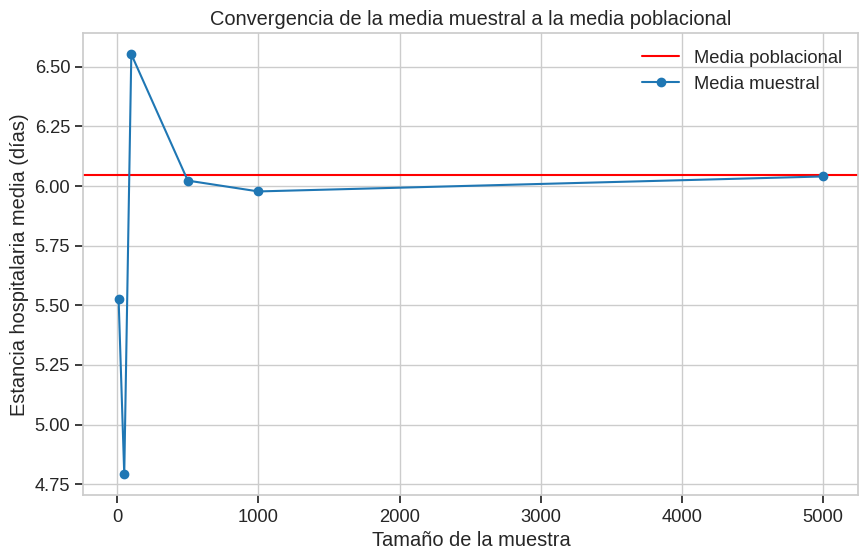

,Tamaño de muestra,Media muestral,Error
0,10,5.526385,0.518320
1,50,4.791664,1.253041
2,100,6.552197,0.507492
3,500,6.022562,0.022143
4,1000,5.977164,0.067541
5,5000,6.039947,0.004758


In [ ]:
# Evaluamos cómo se comporta la estimación con distintos tamaños de muestra
tamanos_muestra = [10, 50, 100, 500, 1000, 5000]
estimaciones = []

for n in tamanos_muestra:
    muestra = np.random.choice(poblacion_estancia, size=n, replace=False)
    estimaciones.append(np.mean(muestra))

# Visualizamos la convergencia
plt.figure(figsize=(10, 6))
plt.axhline(y=media_poblacional, color='r', linestyle='-', label='Media poblacional')
plt.plot(tamanos_muestra, estimaciones, 'o-', label='Media muestral')
plt.xlabel('Tamaño de la muestra')
plt.ylabel('Estancia hospitalaria media (días)')
plt.title('Convergencia de la media muestral a la media poblacional')
plt.legend()
plt.grid(True)
plt.show()

# Tabla de resultados
resultados = pd.DataFrame({
    'Tamaño de muestra': tamanos_muestra,
    'Media muestral': estimaciones,
    'Error': [abs(est - media_poblacional) for est in estimaciones]
})
resultados


---

### 📏 Estimación por intervalos: Intervalos de confianza

Un **intervalo de confianza (IC)** proporciona un rango de valores dentro del cual es razonable pensar que se encuentra un parámetro poblacional desconocido, con un cierto nivel de confianza.

> Por ejemplo, un IC del 95% indica que, si tomáramos muchas muestras y construyéramos un intervalo con cada una, aproximadamente el 95% de estos contendrían el verdadero parámetro poblacional.

#### 🧩 Componentes de un intervalo de confianza:

- 📌 **Estimador puntual** (ej. media muestral): centro del intervalo
- 📐 **Error estándar**: mide la variabilidad del estimador
- 🧭 **Nivel de confianza**: típicamente 90%, 95% o 99%
- 🧮 **Valor crítico**: determinado por la distribución del estimador

#### 📘 Fórmula general del intervalo de confianza:

$$
\text{IC} = \text{Estimador} \pm (\text{Valor crítico} \times \text{Error estándar})
$$

Vamos a calcular un intervalo de confianza del 95% para la media de la estancia hospitalaria.


In [ ]:
# Usamos la muestra anterior
n = len(muestra)
media = np.mean(muestra)
desv_est = np.std(muestra, ddof=1)
error_estandar = desv_est / np.sqrt(n)
confianza = 0.95
grados_libertad = n - 1
valor_t = stats.t.ppf((1 + confianza) / 2, grados_libertad)

# Cálculo del intervalo
margen_error = valor_t * error_estandar
intervalo_inferior = media - margen_error
intervalo_superior = media + margen_error

print(f"Media muestral: {media:.2f} días")
print(f"Intervalo de confianza del 95%: ({intervalo_inferior:.2f}, {intervalo_superior:.2f}) días")
print(f"¿El intervalo contiene la media poblacional ({media_poblacional:.2f})? {intervalo_inferior <= media_poblacional <= intervalo_superior}")


Media muestral: 6.04 días
Intervalo de confianza del 95%: (5.92, 6.16) días
¿El intervalo contiene la media poblacional (6.04)? True


---

### 📊 Visualización del concepto de intervalos de confianza

Para comprender mejor cómo funcionan los intervalos de confianza, simularemos la toma de múltiples muestras aleatorias de la población y construiremos un IC del 95% para cada una.

Esta simulación nos permitirá observar:

- Qué porcentaje de los intervalos construidos contienen la verdadera media poblacional.
- Cómo varía la posición y la amplitud de los intervalos.
- La importancia del azar en el proceso de muestreo.

🔍 En este ejercicio esperamos que aproximadamente 95% de los intervalos contengan el valor real de la media poblacional.


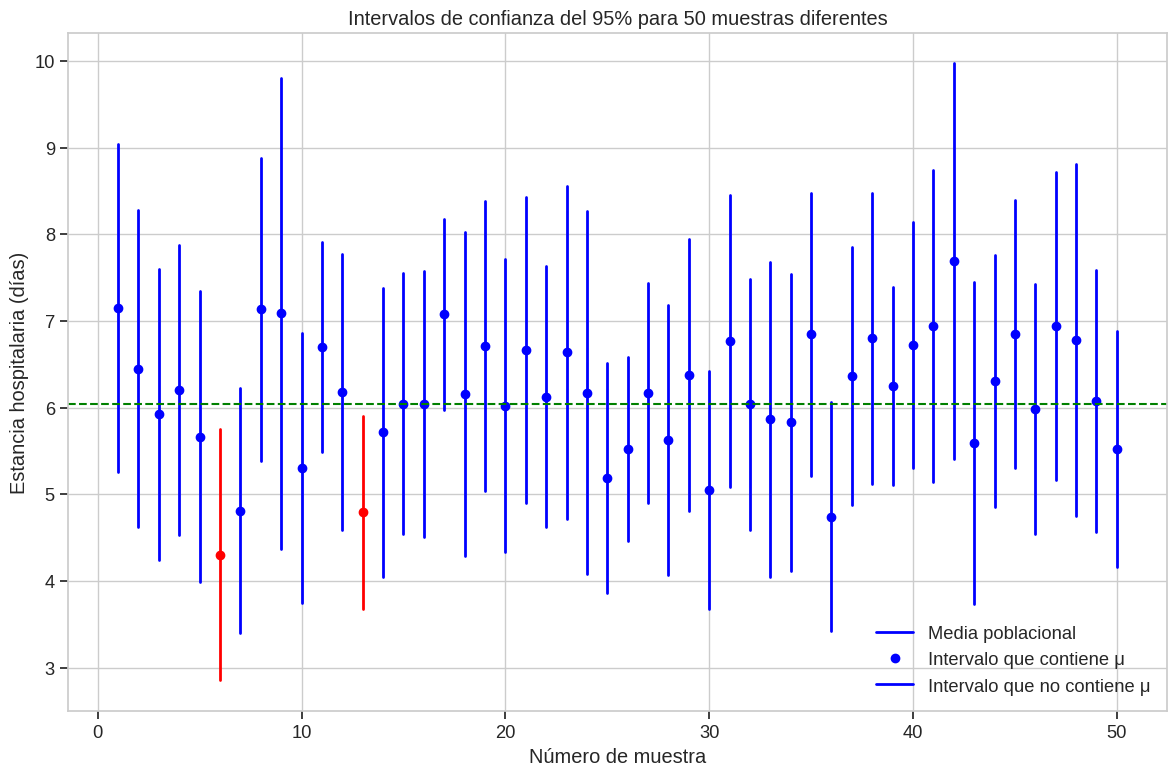

Porcentaje de intervalos que contienen la media poblacional: 96.0%
Esperado teóricamente para IC del 95%: 95.0%


In [ ]:
# Simular 50 muestras y calcular IC para cada una
np.random.seed(123)
n_simulaciones = 50
tamano_muestra = 30
intervalos = []
medias_muestrales = []
contiene_parametro = []

plt.figure(figsize=(12, 8))

for i in range(n_simulaciones):
    muestra = np.random.choice(poblacion_estancia, size=tamano_muestra, replace=False)
    media = np.mean(muestra)
    medias_muestrales.append(media)

    desv_est = np.std(muestra, ddof=1)
    error_estandar = desv_est / np.sqrt(tamano_muestra)
    valor_t = stats.t.ppf(0.975, tamano_muestra - 1)
    margen_error = valor_t * error_estandar

    intervalo_inf = media - margen_error
    intervalo_sup = media + margen_error
    intervalos.append((intervalo_inf, intervalo_sup))

    contiene = intervalo_inf <= media_poblacional <= intervalo_sup
    contiene_parametro.append(contiene)

    color = 'blue' if contiene else 'red'
    plt.plot([i+1, i+1], [intervalo_inf, intervalo_sup], color=color, linewidth=2)
    plt.plot(i+1, media, 'o', color=color)

# Línea de referencia: media poblacional
plt.axhline(y=media_poblacional, color='green', linestyle='--', label='Media poblacional')
plt.xlabel('Número de muestra')
plt.ylabel('Estancia hospitalaria (días)')
plt.title('Intervalos de confianza del 95% para 50 muestras diferentes')
plt.legend(['Media poblacional', 'Intervalo que contiene μ', 'Intervalo que no contiene μ'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Porcentaje de intervalos que contienen el verdadero parámetro
porcentaje_contiene = sum(contiene_parametro) / n_simulaciones * 100
print(f"Porcentaje de intervalos que contienen la media poblacional: {porcentaje_contiene:.1f}%")
print(f"Esperado teóricamente para IC del 95%: 95.0%")


---

## 3. Aplicación en el proyecto: *Análisis de variabilidad regional en tasas de natalidad y GRD*

Vamos a aplicar los conceptos de estimación puntual e intervalos de confianza a un conjunto de datos simulados que representan información hospitalaria en las 16 regiones de Chile. Esta información incluye:

- **Tasa de natalidad** (por 1.000 habitantes)
- **Proporción de cesáreas**
- **Estancia hospitalaria media**
- **Severidad del caso (GRD)**
- **Costo GRD ajustado**

Esta simulación permite ilustrar cómo estas métricas varían regionalmente y cómo cuantificar la incertidumbre en cada estimación.

---

### 🧪 Generación de datos simulados


In [ ]:
# Simulamos datos para 16 regiones de Chile
np.random.seed(123)
regiones = ['Arica y Parinacota', 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo',
            'Valparaíso', 'Metropolitana', 'O\'Higgins', 'Maule', 'Ñuble', 'Biobío',
            'Araucanía', 'Los Ríos', 'Los Lagos', 'Aysén', 'Magallanes']

# Parámetros para cada región
tasas_natalidad_mean = np.array([13.2, 13.8, 14.1, 14.5, 13.5,
                                 12.8, 12.5, 13.2, 13.7, 13.1,
                                 12.9, 14.0, 13.4, 14.2, 13.6, 12.3])

tasas_natalidad_std = np.array([1.5, 1.6, 1.7, 1.8, 1.5,
                                1.4, 1.3, 1.5, 1.6, 1.4,
                                1.4, 1.6, 1.5, 1.7, 1.6, 1.3]) * 0.7

tamanos_muestra = [50, 70, 100, 60, 120,
                   200, 500, 150, 140, 80,
                   220, 130, 70, 110, 40, 50]

# Simulación de datos
datos_regionales = []

for i, region in enumerate(regiones):
    natalidad_regional = np.random.normal(tasas_natalidad_mean[i],
                                          tasas_natalidad_std[i],
                                          tamanos_muestra[i])

    for tasa in natalidad_regional:
        prop_cesarea = 0.25 + 0.02 * (tasa - 12) + np.random.normal(0, 0.05)
        prop_cesarea = max(0.15, min(0.6, prop_cesarea))

        if random.random() < prop_cesarea:
            tipo_parto = 'Cesárea'
            estancia = np.random.gamma(shape=3, scale=1.2) + 2
            severidad = np.random.choice([0, 1, 2, 3], p=[0.1, 0.3, 0.4, 0.2])
            costo_base = 2800000 + np.random.normal(0, 300000)
        else:
            tipo_parto = 'Normal'
            estancia = np.random.gamma(shape=2, scale=1) + 1
            severidad = np.random.choice([0, 1, 2, 3], p=[0.3, 0.4, 0.2, 0.1])
            costo_base = 1500000 + np.random.normal(0, 200000)

        costo = costo_base * (1 + 0.2 * severidad) * (1 + 0.1 * (estancia / 3))

        datos_regionales.append({
            'Region': region,
            'Tasa_Natalidad': tasa,
            'Tipo_Parto': tipo_parto,
            'Estancia_Media': estancia,
            'Severidad': severidad,
            'Costo_GRD': costo
        })

# Crear DataFrame
df_natalidad_grd = pd.DataFrame(datos_regionales)

# Vista preliminar
df_natalidad_grd.head()


,Region,Tasa_Natalidad,Tipo_Parto,Estancia_Media,Severidad,Costo_GRD
0,Arica y Parinacota,12.060088,Normal,1.653132,1,1.906704e+06
1,Arica y Parinacota,14.247213,Normal,4.101289,1,2.524828e+06
2,Arica y Parinacota,13.497127,Normal,3.917840,1,2.419644e+06
3,Arica y Parinacota,11.618391,Normal,2.726087,0,1.585450e+06
4,Arica y Parinacota,12.592470,Normal,1.807451,1,1.368204e+06


---

### 🔍 Exploración inicial de los datos

Antes de aplicar técnicas de estimación, es fundamental conocer la estructura y distribución de los datos. Exploraremos:

- Estadísticos descriptivos de las variables numéricas
- Distribución de tipos de parto
- Distribución de severidad de los casos GRD

Esta exploración permite identificar patrones generales y posibles problemas de calidad de datos o sesgos.


In [ ]:
# Estadísticas descriptivas de variables numéricas
print("Resumen estadístico de las variables numéricas:")
display(df_natalidad_grd[['Tasa_Natalidad', 'Estancia_Media', 'Severidad', 'Costo_GRD']].describe().T)


Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Tasa_Natalidad,2090.0,1.317395e+01,1.212387e+00,9.985383e+00,1.233124e+01,1.312274e+01,1.392174e+01,1.835018e+01
Estancia_Media,2090.0,3.805996e+00,2.075685e+00,1.041881e+00,2.259385e+00,3.353125e+00,4.804366e+00,1.603454e+01
Severidad,2090.0,1.261722e+00,9.606519e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00
Costo_GRD,2090.0,2.704891e+06,1.251646e+06,1.042666e+06,1.805602e+06,2.200084e+06,3.459471e+06,7.912693e+06


In [ ]:
# Distribución relativa de tipos de parto
print("\nDistribución de tipos de parto:")
display((df_natalidad_grd['Tipo_Parto'].value_counts(normalize=True) * 100).to_frame())



Distribución de tipos de parto:


,proportion
Tipo_Parto,
Normal,72.200957
Cesárea,27.799043


In [ ]:
# Distribución relativa de niveles de severidad
print("\nDistribución de severidad:")
display((df_natalidad_grd['Severidad'].value_counts(normalize=True) * 100).to_frame())



Distribución de severidad:


,proportion
Severidad,
1,37.511962
2,26.028708
0,24.258373
3,12.200957


---

### 📍 Estimación puntual para tasas de natalidad por región

Calcularemos la media, desviación estándar y tamaño muestral de la **tasa de natalidad** para cada una de las 16 regiones. Esta estimación puntual nos permitirá tener un primer acercamiento comparativo entre regiones.

Además, incluiremos también:

- La estancia hospitalaria media
- El costo GRD medio

Estos indicadores son fundamentales para evaluar la eficiencia y variabilidad del sistema hospitalario a nivel regional.


In [ ]:
# Cálculo de estadísticas por región
estadisticos_regionales = df_natalidad_grd.groupby('Region').agg({
    'Tasa_Natalidad': ['mean', 'std', 'count'],
    'Estancia_Media': ['mean', 'std'],
    'Costo_GRD': ['mean', 'std']
})

# Renombrar columnas
estadisticos_regionales.columns = ['_'.join(col).strip() for col in estadisticos_regionales.columns.values]
estadisticos_regionales = estadisticos_regionales.reset_index()

# Mostrar resultados
estadisticos_regionales


,Region,Tasa_Natalidad_mean,Tasa_Natalidad_std,Tasa_Natalidad_count,Estancia_Media_mean,Estancia_Media_std,Costo_GRD_mean,Costo_GRD_std
0,Antofagasta,14.103638,1.298157,100,3.695134,1.733903,2.556346e+06,1.122370e+06
1,Araucanía,13.998772,1.042622,130,3.907626,2.058138,2.860777e+06,1.285584e+06
2,Arica y Parinacota,13.213935,1.261786,50,3.609699,1.791693,2.869232e+06,1.272937e+06
3,Atacama,14.675722,1.272353,60,3.876946,1.969397,2.785492e+06,1.309606e+06
4,Aysén,13.657590,1.032064,40,4.708285,2.542095,3.216887e+06,1.350927e+06
5,Biobío,12.826851,1.124999,220,3.905262,2.198181,2.827902e+06,1.339595e+06
6,Coquimbo,13.430727,1.012323,120,3.556603,2.064141,2.448205e+06,1.172590e+06
7,Los Lagos,14.272750,1.252614,110,4.055849,2.388295,2.957424e+06,1.296664e+06
8,Los Ríos,13.249762,1.064894,70,3.668015,2.256085,2.536177e+06,1.192283e+06
9,Magallanes,12.171513,0.974335,50,3.452174,1.528931,2.514071e+06,1.089988e+06


---

### 📏 Intervalos de confianza para las tasas de natalidad por región

Ahora aplicaremos la fórmula del intervalo de confianza para la media a las tasas de natalidad de cada región. Utilizaremos un nivel de confianza del 95%.

Esto nos permitirá:

- Evaluar la precisión de cada estimación
- Comparar regiones con consideración de la incertidumbre
- Identificar posibles diferencias estadísticamente significativas entre regiones


In [ ]:
# Función para calcular IC de la media
def calcular_ic_media(media, desv_est, n, confianza=0.95):
    error_estandar = desv_est / np.sqrt(n)
    valor_critico = stats.t.ppf((1 + confianza) / 2, n - 1)
    margen_error = valor_critico * error_estandar
    return media - margen_error, media + margen_error


In [ ]:
# Calcular IC para cada región
resultados_ic = []

for _, row in estadisticos_regionales.iterrows():
    region = row['Region']
    media = row['Tasa_Natalidad_mean']
    desv_est = row['Tasa_Natalidad_std']
    n = row['Tasa_Natalidad_count']

    ic_inferior, ic_superior = calcular_ic_media(media, desv_est, n)

    resultados_ic.append({
        'Region': region,
        'Media': media,
        'Desv_Est': desv_est,
        'Tamaño_Muestra': n,
        'IC_Inferior': ic_inferior,
        'IC_Superior': ic_superior,
        'Amplitud_IC': ic_superior - ic_inferior
    })

# Convertir a DataFrame
df_intervalos = pd.DataFrame(resultados_ic)
df_intervalos = df_intervalos.sort_values('Media', ascending=False)

# Mostrar resultados
df_intervalos


,Region,Media,Desv_Est,Tamaño_Muestra,IC_Inferior,IC_Superior,Amplitud_IC
3,Atacama,14.675722,1.272353,60,14.347038,15.004405,0.657367
7,Los Lagos,14.272750,1.252614,110,14.036039,14.509460,0.473421
0,Antofagasta,14.103638,1.298157,100,13.846055,14.361220,0.515165
1,Araucanía,13.998772,1.042622,130,13.817848,14.179696,0.361848
13,Tarapacá,13.715677,1.027319,70,13.470722,13.960633,0.489911
4,Aysén,13.657590,1.032064,40,13.327520,13.987660,0.660140
10,Maule,13.555939,1.112342,140,13.370065,13.741814,0.371749
6,Coquimbo,13.430727,1.012323,120,13.247742,13.613712,0.365970
8,Los Ríos,13.249762,1.064894,70,12.995847,13.503677,0.507830
2,Arica y Parinacota,13.213935,1.261786,50,12.855340,13.572530,0.717191


---

### 📊 Visualización de los intervalos de confianza para tasas de natalidad por región

Una representación gráfica de los intervalos de confianza facilita la comparación entre regiones y permite identificar diferencias estadísticamente significativas.

Observa que:

- Cuanto más estrecho es el intervalo, mayor precisión en la estimación.
- Si los intervalos entre regiones no se superponen, puede indicar diferencias significativas.


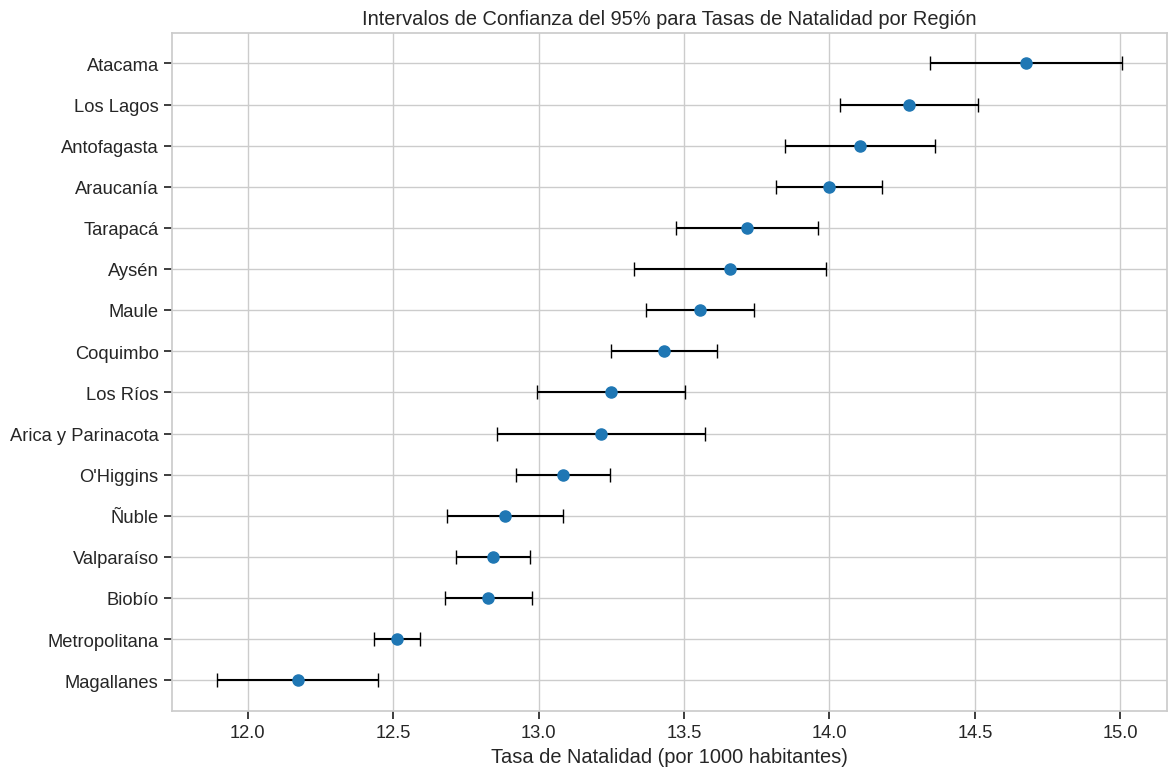

In [ ]:
# Ordenar datos para visualización
df_plot = df_intervalos.sort_values('Media', ascending=True).reset_index()

# Visualización
plt.figure(figsize=(12, 8))

plt.errorbar(
    df_plot['Media'], df_plot.index,
    xerr=[df_plot['Media'] - df_plot['IC_Inferior'], df_plot['IC_Superior'] - df_plot['Media']],
    fmt='o', capsize=5, capthick=1, ecolor='black', markersize=8
)

plt.yticks(df_plot.index, df_plot['Region'])
plt.xlabel('Tasa de Natalidad (por 1000 habitantes)')
plt.title('Intervalos de Confianza del 95% para Tasas de Natalidad por Región')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


---

### ⚕️ Intervalos de confianza para proporciones: Tasa de cesáreas por región

Además de estimar medias, también podemos construir intervalos de confianza para proporciones, por ejemplo:

> **¿Qué proporción de partos fueron cesáreas en cada región?**

Usaremos el método de **Wilson** para calcular intervalos de confianza del 95% para proporciones, ya que ofrece mejor cobertura en muestras pequeñas o proporciones extremas que el método clásico de Wald.


In [ ]:
# Calcular proporción de cesáreas y su IC 95% por región
resultados_cesarea = []

for region in regiones:
    datos_region = df_natalidad_grd[df_natalidad_grd['Region'] == region]

    n_cesarea = sum(datos_region['Tipo_Parto'] == 'Cesárea')
    n_total = len(datos_region)
    proporcion = n_cesarea / n_total

    ic_inferior, ic_superior = proportion_confint(n_cesarea, n_total, alpha=0.05, method='wilson')

    resultados_cesarea.append({
        'Region': region,
        'Proporcion_Cesarea': proporcion,
        'n_Cesarea': n_cesarea,
        'n_Total': n_total,
        'IC_Inferior': ic_inferior,
        'IC_Superior': ic_superior,
        'Amplitud_IC': ic_superior - ic_inferior
    })

# Convertir a DataFrame
df_cesarea = pd.DataFrame(resultados_cesarea)
df_cesarea = df_cesarea.sort_values('Proporcion_Cesarea', ascending=False)

# Mostrar resultados
df_cesarea


,Region,Proporcion_Cesarea,n_Cesarea,n_Total,IC_Inferior,IC_Superior,Amplitud_IC
1,Tarapacá,0.414286,29,70,0.306302,0.531188,0.224886
14,Aysén,0.400000,16,40,0.263483,0.554041,0.290558
0,Arica y Parinacota,0.380000,19,50,0.258628,0.518496,0.259868
13,Los Lagos,0.354545,39,110,0.271441,0.447466,0.176024
11,Araucanía,0.346154,45,130,0.269850,0.431288,0.161438
10,Biobío,0.322727,71,220,0.264448,0.387091,0.122643
3,Atacama,0.300000,18,60,0.198982,0.425087,0.226105
5,Valparaíso,0.275000,55,200,0.217797,0.340683,0.122886
7,O'Higgins,0.266667,40,150,0.202372,0.342615,0.140243
9,Ñuble,0.262500,21,80,0.178574,0.368190,0.189616


---

### 📊 Visualización de los intervalos de confianza para tasas de cesáreas por región

Al igual que con las tasas de natalidad, es importante visualizar la proporción de cesáreas y su intervalo de confianza.

Esta representación permite:

- Detectar regiones con tasas elevadas o bajas de cesáreas
- Evaluar la precisión de la estimación (amplitud del IC)
- Identificar posibles prácticas clínicas distintas entre regiones


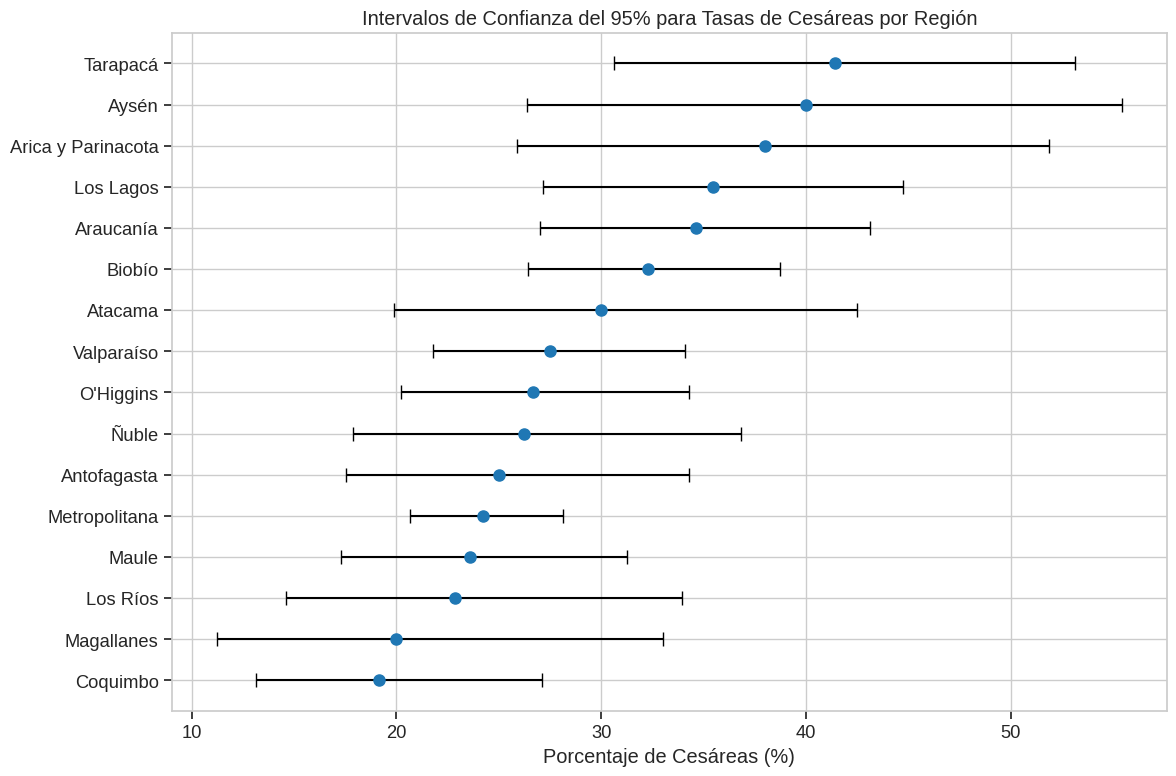

In [ ]:
# Preparar datos
df_plot = df_cesarea.sort_values('Proporcion_Cesarea', ascending=True).reset_index()

# Visualización
plt.figure(figsize=(12, 8))

plt.errorbar(
    df_plot['Proporcion_Cesarea'] * 100, df_plot.index,
    xerr=[
        (df_plot['Proporcion_Cesarea'] - df_plot['IC_Inferior']) * 100,
        (df_plot['IC_Superior'] - df_plot['Proporcion_Cesarea']) * 100
    ],
    fmt='o', capsize=5, capthick=1, ecolor='black', markersize=8
)

plt.yticks(df_plot.index, df_plot['Region'])
plt.xlabel('Porcentaje de Cesáreas (%)')
plt.title('Intervalos de Confianza del 95% para Tasas de Cesáreas por Región')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


---

### 💰 Intervalos de confianza para los costos medios por región

Finalmente, calcularemos intervalos de confianza del 95% para el **costo promedio GRD** por región.

Este análisis es crucial para:

- Identificar regiones con costos significativamente mayores o menores
- Evaluar la variabilidad en el uso de recursos hospitalarios
- Informar decisiones de asignación presupuestaria basada en datos

Usaremos nuevamente el método clásico para la media, suponiendo que los tamaños muestrales regionales son suficientemente grandes.


In [ ]:
# Cálculo de IC para costos promedio por región
resultados_costos = []

for region in regiones:
    datos_region = df_natalidad_grd[df_natalidad_grd['Region'] == region]
    n = len(datos_region)
    media = datos_region['Costo_GRD'].mean()
    desv_est = datos_region['Costo_GRD'].std()

    ic_inferior, ic_superior = calcular_ic_media(media, desv_est, n)

    resultados_costos.append({
        'Region': region,
        'Costo_Medio': media,
        'Desv_Est': desv_est,
        'Tamaño_Muestra': n,
        'IC_Inferior': ic_inferior,
        'IC_Superior': ic_superior,
        'Amplitud_IC': ic_superior - ic_inferior
    })

# Crear DataFrame
df_costos = pd.DataFrame(resultados_costos)
df_costos = df_costos.sort_values('Costo_Medio', ascending=False)

# Mostrar resultados
df_costos


,Region,Costo_Medio,Desv_Est,Tamaño_Muestra,IC_Inferior,IC_Superior,Amplitud_IC
14,Aysén,3.216887e+06,1.350927e+06,40,2.784839e+06,3.648934e+06,864094.713967
1,Tarapacá,3.099992e+06,1.414799e+06,70,2.762645e+06,3.437339e+06,674693.759856
13,Los Lagos,2.957424e+06,1.296664e+06,110,2.712389e+06,3.202458e+06,490069.369739
0,Arica y Parinacota,2.869232e+06,1.272937e+06,50,2.507467e+06,3.230997e+06,723529.576927
11,Araucanía,2.860777e+06,1.285584e+06,130,2.637692e+06,3.083862e+06,446169.942308
10,Biobío,2.827902e+06,1.339595e+06,220,2.649903e+06,3.005901e+06,355997.519699
3,Atacama,2.785492e+06,1.309606e+06,60,2.447185e+06,3.123799e+06,676614.345818
5,Valparaíso,2.715900e+06,1.285655e+06,200,2.536631e+06,2.895170e+06,358539.245932
7,O'Higgins,2.682927e+06,1.260524e+06,150,2.479553e+06,2.886301e+06,406747.893471
9,Ñuble,2.672759e+06,1.204979e+06,80,2.404604e+06,2.940914e+06,536309.846712


---

### 📊 Visualización comparativa de intervalos de confianza por región

Vamos a crear una visualización conjunta de los intervalos de confianza de tres indicadores clave por región:

1. **Tasa de natalidad**
2. **Proporción de cesáreas**
3. **Costo promedio GRD**

Esta comparación simultánea facilita:

- Identificar patrones regionales consistentes
- Detectar regiones con alta carga asistencial y alto costo
- Apoyar decisiones de gestión con base en múltiples indicadores

📌 Se utiliza el mismo orden de regiones para facilitar la comparación.


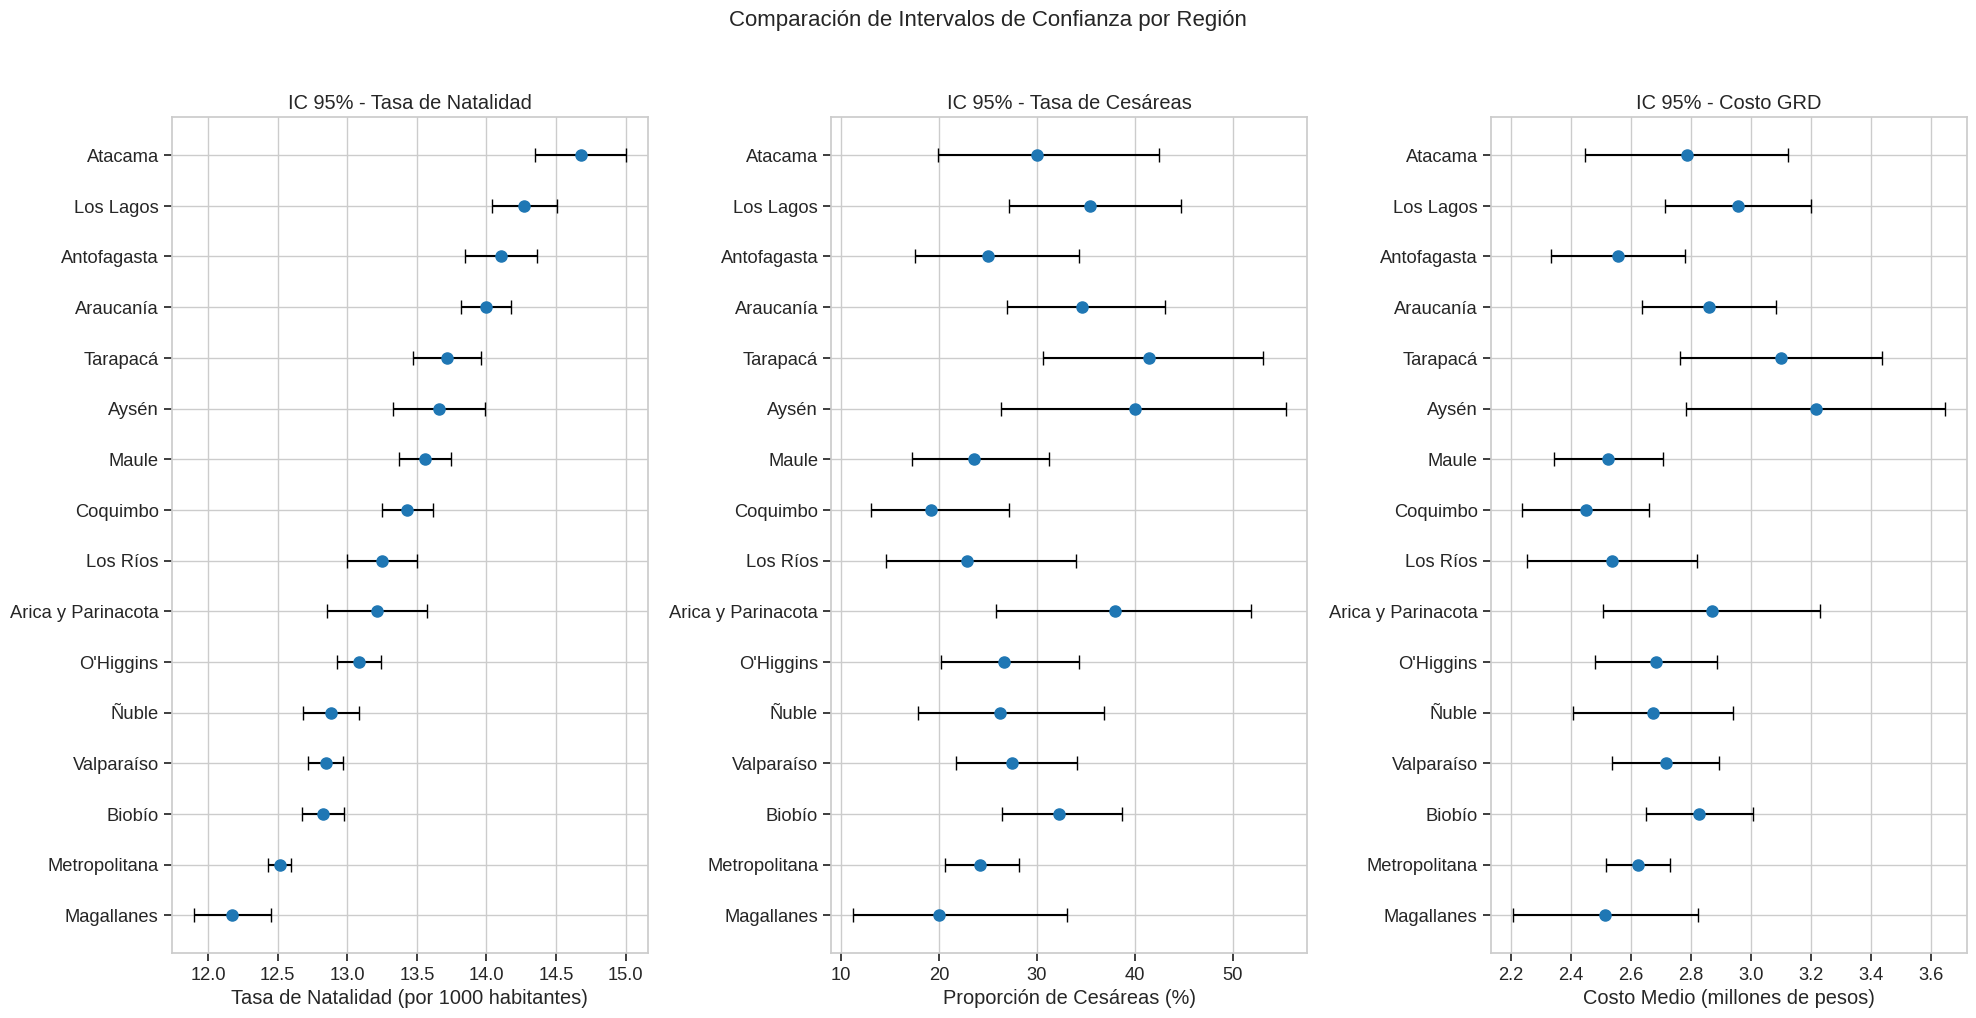

In [ ]:
# Crear visualización comparativa de IC para natalidad, cesáreas y costos

# Establecer orden de regiones para alinearlas en los tres gráficos
regiones_ordenadas = df_intervalos.sort_values('Media', ascending=True)['Region'].values
orden_regiones = {region: i for i, region in enumerate(regiones_ordenadas)}

def get_region_index(region):
    return orden_regiones[region]

# Configurar figura
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# 1. Tasa de natalidad
ax1 = axes[0]
df_plot = df_intervalos.sort_values('Media', ascending=True).reset_index()
ax1.errorbar(df_plot['Media'], df_plot.index,
             xerr=[df_plot['Media'] - df_plot['IC_Inferior'], df_plot['IC_Superior'] - df_plot['Media']],
             fmt='o', capsize=5, ecolor='black', markersize=8)
ax1.set_yticks(df_plot.index)
ax1.set_yticklabels(df_plot['Region'])
ax1.set_xlabel('Tasa de Natalidad (por 1000 habitantes)')
ax1.set_title('IC 95% - Tasa de Natalidad')
ax1.grid(True, axis='x')

# 2. Proporción de cesáreas
ax2 = axes[1]
df_plot = df_cesarea.copy()
df_plot['Region_Index'] = df_plot['Region'].apply(get_region_index)
df_plot = df_plot.sort_values('Region_Index').reset_index()
ax2.errorbar(df_plot['Proporcion_Cesarea'] * 100, df_plot.index,
             xerr=[
                 (df_plot['Proporcion_Cesarea'] - df_plot['IC_Inferior']) * 100,
                 (df_plot['IC_Superior'] - df_plot['Proporcion_Cesarea']) * 100
             ],
             fmt='o', capsize=5, ecolor='black', markersize=8)
ax2.set_yticks(df_plot.index)
ax2.set_yticklabels(df_plot['Region'])
ax2.set_xlabel('Proporción de Cesáreas (%)')
ax2.set_title('IC 95% - Tasa de Cesáreas')
ax2.grid(True, axis='x')

# 3. Costo GRD
ax3 = axes[2]
df_plot = df_costos.copy()
df_plot['Region_Index'] = df_plot['Region'].apply(get_region_index)
df_plot = df_plot.sort_values('Region_Index').reset_index()
ax3.errorbar(df_plot['Costo_Medio'] / 1e6, df_plot.index,
             xerr=[
                 (df_plot['Costo_Medio'] - df_plot['IC_Inferior']) / 1e6,
                 (df_plot['IC_Superior'] - df_plot['Costo_Medio']) / 1e6
             ],
             fmt='o', capsize=5, ecolor='black', markersize=8)
ax3.set_yticks(df_plot.index)
ax3.set_yticklabels(df_plot['Region'])
ax3.set_xlabel('Costo Medio (millones de pesos)')
ax3.set_title('IC 95% - Costo GRD')
ax3.grid(True, axis='x')

# Título general
plt.suptitle('Comparación de Intervalos de Confianza por Región', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


---

## 4. Factores que afectan la amplitud de los intervalos de confianza

La **amplitud del intervalo de confianza** indica cuánta incertidumbre hay en la estimación.

Los tres factores principales que determinan su tamaño son:

1. **🔢 Tamaño de la muestra (n)**  
   - A mayor tamaño de muestra, menor error estándar → intervalo más estrecho.

2. **📊 Variabilidad en los datos (desviación estándar σ)**  
   - A mayor dispersión en los datos, mayor amplitud del intervalo.

3. **🔒 Nivel de confianza (ej. 90%, 95%, 99%)**  
   - A mayor nivel de confianza, mayor será el valor crítico y, por tanto, la amplitud.

Visualizaremos estos efectos utilizando datos reales simulados para una región específica.


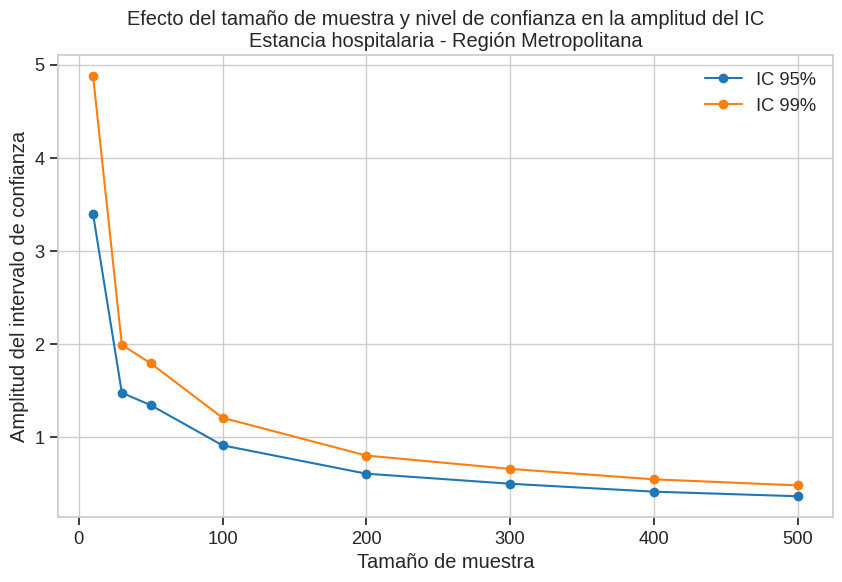

In [ ]:
# Datos de ejemplo: región Metropolitana
region_ejemplo = 'Metropolitana'
datos_region = df_natalidad_grd[df_natalidad_grd['Region'] == region_ejemplo]
estancia = datos_region['Estancia_Media'].values

# Evaluar efecto del tamaño muestral y nivel de confianza
tamanos_muestra = [10, 30, 50, 100, 200, 300, 400, 500]
amplitudes_95 = []
amplitudes_99 = []

for n in tamanos_muestra:
    if n <= len(estancia):
        muestra = np.random.choice(estancia, size=n, replace=False)
        media = np.mean(muestra)
        desv_est = np.std(muestra, ddof=1)

        # IC 95%
        ic_inf_95, ic_sup_95 = calcular_ic_media(media, desv_est, n, confianza=0.95)
        amplitudes_95.append(ic_sup_95 - ic_inf_95)

        # IC 99%
        ic_inf_99, ic_sup_99 = calcular_ic_media(media, desv_est, n, confianza=0.99)
        amplitudes_99.append(ic_sup_99 - ic_inf_99)

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(tamanos_muestra, amplitudes_95, 'o-', label='IC 95%')
plt.plot(tamanos_muestra, amplitudes_99, 'o-', label='IC 99%')
plt.xlabel('Tamaño de muestra')
plt.ylabel('Amplitud del intervalo de confianza')
plt.title(f'Efecto del tamaño de muestra y nivel de confianza en la amplitud del IC\nEstancia hospitalaria - Región {region_ejemplo}')
plt.legend()
plt.grid(True)
plt.show()


---

## 5. Inferencia a partir de intervalos de confianza

Los intervalos de confianza no solo permiten estimar parámetros, sino también **realizar comparaciones entre grupos** y **detectar diferencias significativas**.

Algunas aplicaciones clave incluyen:

1. **Comparación de grupos**  
   Si los intervalos de dos regiones no se superponen, podemos sospechar una diferencia estadísticamente significativa.

2. **Evaluación de referencia nacional**  
   Podemos comparar los intervalos regionales con un valor nacional (promedio ponderado) para identificar regiones "fuera de norma".

3. **Identificación de valores extremos**  
   Regiones cuyos intervalos no contienen el valor nacional podrían ser priorizadas para evaluación o intervención.

En esta sección, compararemos las tasas de natalidad regionales con el promedio nacional.


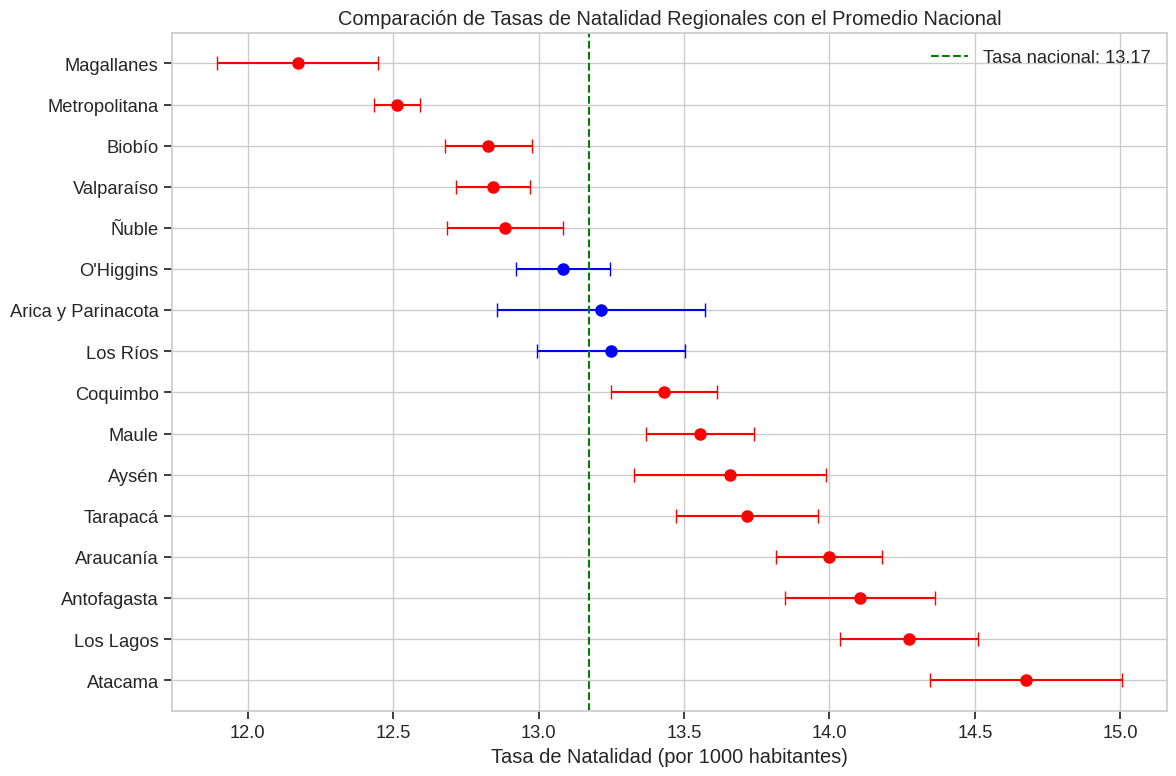

In [ ]:
# Ordenar regiones por tasa de natalidad media
df_nat_ordenado = df_intervalos.sort_values('Media', ascending=False).reset_index(drop=True)

# Calcular tasa nacional ponderada
tasa_nacional = sum(df_nat_ordenado['Media'] * df_nat_ordenado['Tamaño_Muestra']) / sum(df_nat_ordenado['Tamaño_Muestra'])

# Identificar regiones cuyo IC no contiene la tasa nacional
df_nat_ordenado['Difiere_Nacional'] = ~(
    (df_nat_ordenado['IC_Inferior'] <= tasa_nacional) &
    (df_nat_ordenado['IC_Superior'] >= tasa_nacional)
)

# Visualización
plt.figure(figsize=(12, 8))

for i, row in df_nat_ordenado.iterrows():
    color = 'red' if row['Difiere_Nacional'] else 'blue'
    plt.errorbar(
        row['Media'], i,
        xerr=[[row['Media'] - row['IC_Inferior']], [row['IC_Superior'] - row['Media']]],
        fmt='o', capsize=5, color=color, ecolor=color, markersize=8
    )

# Línea vertical con el valor nacional
plt.axvline(x=tasa_nacional, color='green', linestyle='--', label=f'Tasa nacional: {tasa_nacional:.2f}')

plt.yticks(range(len(df_nat_ordenado)), df_nat_ordenado['Region'])
plt.xlabel('Tasa de Natalidad (por 1000 habitantes)')
plt.title('Comparación de Tasas de Natalidad Regionales con el Promedio Nacional')
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()


In [ ]:
# Tabla con interpretación
tabla_resultados = df_nat_ordenado[['Region', 'Media', 'IC_Inferior', 'IC_Superior', 'Difiere_Nacional']]
tabla_resultados.rename(columns={
    'Media': 'Tasa_Natalidad',
    'Difiere_Nacional': 'Difiere_del_Promedio'
}, inplace=True)

tabla_resultados


/tmp/ipykernel_9392/2824358573.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_resultados.rename(columns={


,Region,Tasa_Natalidad,IC_Inferior,IC_Superior,Difiere_del_Promedio
0,Atacama,14.675722,14.347038,15.004405,True
1,Los Lagos,14.272750,14.036039,14.509460,True
2,Antofagasta,14.103638,13.846055,14.361220,True
3,Araucanía,13.998772,13.817848,14.179696,True
4,Tarapacá,13.715677,13.470722,13.960633,True
5,Aysén,13.657590,13.327520,13.987660,True
6,Maule,13.555939,13.370065,13.741814,True
7,Coquimbo,13.430727,13.247742,13.613712,True
8,Los Ríos,13.249762,12.995847,13.503677,False
9,Arica y Parinacota,13.213935,12.855340,13.572530,False


---

## 6. Aplicación a la toma de decisiones en gestión hospitalaria

Los intervalos de confianza permiten a las autoridades sanitarias y equipos de gestión hospitalaria:

- 📉 Estimar con precisión los recursos necesarios
- 🧭 Identificar diferencias regionales relevantes
- 💰 Evaluar el costo esperado y su incertidumbre
- 🎯 Definir umbrales para intervenciones específicas

En esta sección, construiremos un **modelo de predicción del costo GRD** a partir de variables como:

- **Tasa de natalidad**
- **Proporción de cesáreas**

Calcularemos además un **intervalo de predicción** para una nueva región hipotética.


In [ ]:
# Agregamos datos por región
datos_agregados = df_natalidad_grd.groupby('Region').agg({
    'Tasa_Natalidad': 'mean',
    'Costo_GRD': 'mean',
    'Estancia_Media': 'mean',
    'Tipo_Parto': lambda x: (x == 'Cesárea').mean()
}).reset_index()

datos_agregados.rename(columns={'Tipo_Parto': 'Proporcion_Cesarea'}, inplace=True)

# Ajuste del modelo lineal
X = datos_agregados[['Tasa_Natalidad', 'Proporcion_Cesarea']]
X = sm.add_constant(X)
y = datos_agregados['Costo_GRD']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:              Costo_GRD   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     80.18
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           4.87e-08
Time:                        11:41:47   Log-Likelihood:                -198.27
No. Observations:                  16   AIC:                             402.5
Df Residuals:                      13   BIC:                             404.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2.033e+06    3.4

In [ ]:
# Supongamos una nueva región con tasa de natalidad 14 y proporción de cesáreas 0.3
X_nuevo = np.array([1, 14, 0.3]).reshape(1, -1)
y_pred = modelo.predict(X_nuevo)

# Intervalo de predicción al 95%
y_pred_se = np.sqrt(modelo.mse_resid + np.diagonal(X_nuevo @ modelo.cov_params() @ X_nuevo.T))
t_valor = stats.t.ppf(0.975, modelo.df_resid)

y_pred_lower = y_pred - t_valor * y_pred_se
y_pred_upper = y_pred + t_valor * y_pred_se

print(f"\nPara una región con tasa de natalidad de 14 y proporción de cesáreas de 0.3:")
print(f"Costo GRD estimado: ${y_pred[0]:,.0f}")
print(f"Intervalo de predicción 95%: (${y_pred_lower[0]:,.0f}, ${y_pred_upper[0]:,.0f})")



Para una región con tasa de natalidad de 14 y proporción de cesáreas de 0.3:
Costo GRD estimado: $2,759,847
Intervalo de predicción 95%: ($2,611,820, $2,907,875)


---

### 📈 Visualización de la relación entre tasa de natalidad y costo GRD

Visualizaremos la relación entre la tasa de natalidad y el costo promedio GRD, manteniendo fija la proporción de cesáreas.

La visualización incluirá:

- 🔴 Línea de predicción del modelo
- 🔵 Puntos de datos reales (por región)
- 🔶 Bandas de confianza del 95% para las predicciones

Esto permite evaluar tanto la tendencia general como la incertidumbre del modelo.


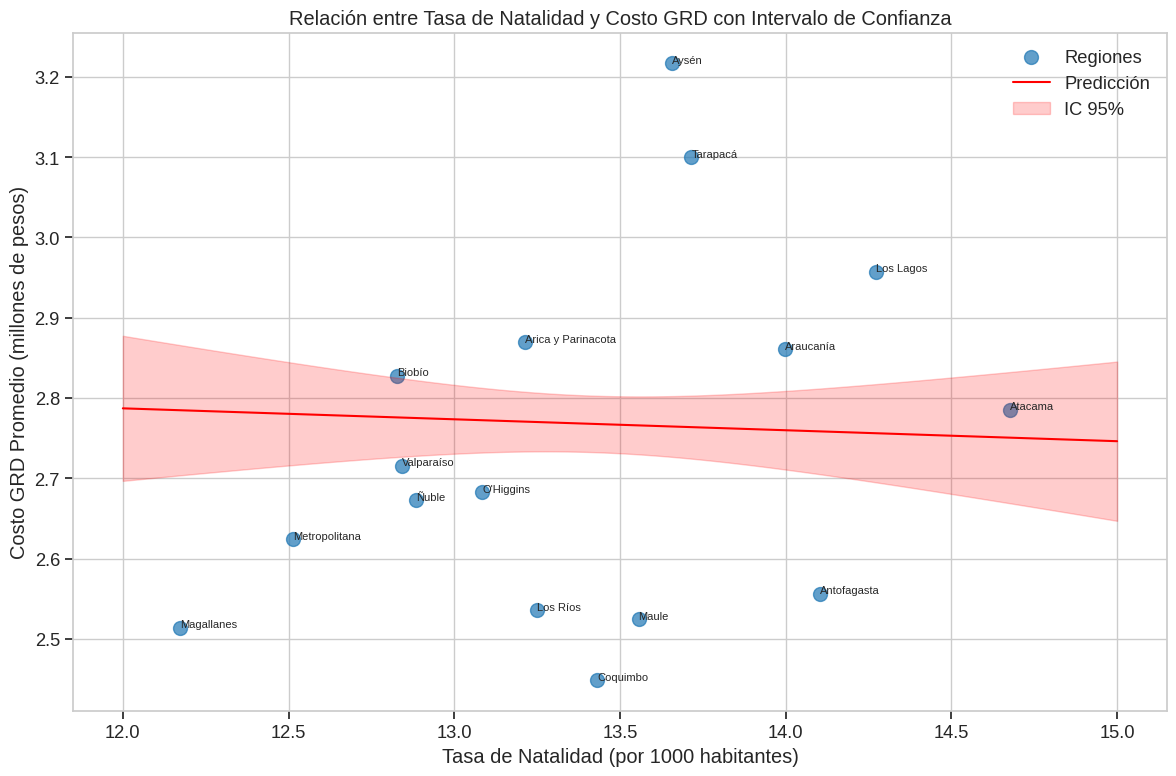

In [ ]:
# Rango de valores para tasa de natalidad
tasa_range = np.linspace(12, 15, 100)
X_pred = sm.add_constant(np.column_stack((tasa_range, np.full_like(tasa_range, 0.3))), has_constant='add')  # proporción fija

# Obtener predicción e IC
y_pred = modelo.get_prediction(X_pred)
y_pred_ci = y_pred.conf_int(alpha=0.05)

# Visualización
plt.figure(figsize=(12, 8))

# Datos reales
plt.scatter(datos_agregados['Tasa_Natalidad'], datos_agregados['Costo_GRD'] / 1e6,
            s=100, alpha=0.7, label='Regiones')

# Línea de predicción
plt.plot(tasa_range, y_pred.predicted_mean / 1e6, 'r-', label='Predicción')

# Bandas de confianza
plt.fill_between(tasa_range, y_pred_ci[:, 0] / 1e6, y_pred_ci[:, 1] / 1e6,
                 alpha=0.2, color='r', label='IC 95%')

# Etiquetas de las regiones
for i, txt in enumerate(datos_agregados['Region']):
    plt.annotate(txt, (datos_agregados['Tasa_Natalidad'][i],
                       datos_agregados['Costo_GRD'][i] / 1e6),
                 fontsize=8)

plt.xlabel('Tasa de Natalidad (por 1000 habitantes)')
plt.ylabel('Costo GRD Promedio (millones de pesos)')
plt.title('Relación entre Tasa de Natalidad y Costo GRD con Intervalo de Confianza')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


---

## 7. Conclusiones e implicaciones para el sistema GRD

El uso de intervalos de confianza aporta valor tanto técnico como práctico al análisis de datos hospitalarios. A través de este notebook, hemos demostrado cómo:

1. ✅ Se puede **cuantificar la incertidumbre** de las estimaciones (medias, proporciones, costos).
2. 📊 Es posible **comparar regiones** en forma válida y estadísticamente fundamentada.
3. 🧭 Se pueden **detectar valores atípicos** o comportamientos anómalos en variables clave.
4. 💡 Los intervalos permiten **predecir costos y recursos requeridos** con márgenes de error conocidos.
5. 🧠 Las decisiones pueden ser **basadas en evidencia** y no sólo en valores puntuales.

---

## Aplicación al contexto GRD en Chile

Este enfoque permite:

- Desarrollar presupuestos más precisos
- Identificar regiones con necesidades o desviaciones específicas
- Evaluar políticas de salud mediante análisis estadístico riguroso
- Informar estrategias de asignación de recursos basadas en evidencia y variabilidad observada


---

## 8. Actividad: Aplicación a sus proyectos GRD

Ahora les corresponde aplicar los conceptos aprendidos en sus propios análisis.

### ✍️ Instrucciones:

1. **Identificación de parámetros clave**  
   - Selecciona al menos 3 parámetros relevantes en tu proyecto (medias, proporciones, costos, etc.).
   - Justifica su importancia en el contexto del GRD que estás analizando.

2. **Estimación y visualización**  
   - Calcula la estimación puntual y el intervalo de confianza del 95% para cada parámetro.
   - Visualiza los resultados de forma clara y comparativa.

3. **Comparación entre grupos**  
   - Selecciona una variable de agrupación (región, tipo de hospital, severidad, etc.).
   - Compara los intervalos de confianza entre grupos.
   - Identifica diferencias estadísticamente significativas.

4. **Interpretación y recomendaciones**  
   - Explica cómo estos análisis pueden informar decisiones en tu contexto.
   - Propón al menos una recomendación concreta basada en tus hallazgos.

---

### 📦 Entregables:

- 🧪 Notebook de Jupyter con código, visualizaciones y explicaciones
- 📈 Gráficos claros y etiquetados
- 📃 Interpretación de los resultados
- 💬 Reflexión sobre la importancia de la incertidumbre en salud y gestión hospitalaria
